# Task 2 - Pipeline Completo

orquesta todo el flujo de Task 2 usando la logica reusable en `src/connect4`: entrenamiento, evaluacion, exportacion del PDF, resumen de analisis y partidas representativas.

Por defecto usa una configuracion de prueba rapida para que puedas ejecutar todas las celdas sin esperar demasiado. Cambia `RUN_PROFILE` a `"full"` en la celda de configuracion cuando quieras la corrida completa de entrega.

In [2]:
from pathlib import Path
import importlib
import json
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, clear_output, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

importlib.invalidate_caches()

MODULE_NAMES = [
    "connect4",
    "connect4.game",
    "connect4.visualization",
    "connect4.task2_report",
    "connect4.task2_analysis",
    "connect4.task2_pipeline",
]

for module_name in MODULE_NAMES:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

from connect4.game import Connect4
from connect4.task2_analysis import extract_representative_matches, replay_match_states
from connect4.task2_pipeline import DEFAULT_TASK2_CONFIG, run_task2_pipeline
from connect4.task2_report import create_task2_results_figure
from connect4.visualization import create_board_figure


## Configuracion

In [3]:
RUN_PROFILE = os.environ.get("TASK2_NOTEBOOK_PROFILE", "full")  # "smoke" o "full"
OUTPUT_DIR_ENV = os.environ.get("TASK2_NOTEBOOK_OUTPUT_DIR")
OUTPUT_DIR = Path(OUTPUT_DIR_ENV) if OUTPUT_DIR_ENV else ROOT / "artifacts" / f"task2_{RUN_PROFILE}"
VISUALS_DIR = OUTPUT_DIR / "notebook_visuals"
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

if RUN_PROFILE == "full":
    training_config = None
    evaluation_config = None
else:
    training_config = {
        "episodes": 6,
        "checkpoint_interval": 3,
        "seed": 15,
        "stats_window_size": 4,
        "initial_epsilon": 0.9,
        "epsilon_end": 0.2,
    }
    evaluation_config = {
        "matches_per_condition": 3,
        "seed": 27,
        "td_epsilon": 0.0,
    }

print(f"Perfil de ejecucion: {RUN_PROFILE}")
print(f"Directorio de salida: {OUTPUT_DIR}")
print(f"Exportaciones visuales: {VISUALS_DIR}")
if RUN_PROFILE == "full":
    print("Configuracion de entrenamiento:", DEFAULT_TASK2_CONFIG["training"])
    print("Configuracion de evaluacion:", DEFAULT_TASK2_CONFIG["evaluation"])
else:
    print("Configuracion de entrenamiento:", training_config)
    print("Configuracion de evaluacion:", evaluation_config)


Perfil de ejecucion: full
Directorio de salida: C:\Users\djlop\OneDrive\DIEGO\UVG\2026\primer semestre\IA\Labs\artifacts\task2_full
Exportaciones visuales: C:\Users\djlop\OneDrive\DIEGO\UVG\2026\primer semestre\IA\Labs\artifacts\task2_full\notebook_visuals
Configuracion de entrenamiento: {'episodes': 500, 'learning_rate': 0.01, 'discount': 0.99, 'initial_epsilon': 1.0, 'epsilon_end': 0.1, 'checkpoint_interval': 500, 'snapshot_start_episode': 1001, 'snapshot_interval': 500, 'frozen_opponent_probability': 0.5, 'seed': 42, 'stats_window_size': 200}
Configuracion de evaluacion: {'matches_per_condition': 50, 'td_epsilon': 0.0, 'minimax_depth': 4, 'alphabeta_depth': 4, 'seed': 99}


## Ejecutar Pipeline

In [4]:
result = run_task2_pipeline(
    OUTPUT_DIR,
    training_config=training_config,
    evaluation_config=evaluation_config,
)

display(Markdown("### Artefactos"))
print("Resumen de entrenamiento:", OUTPUT_DIR / "training" / "training_summary.json")
print("Resumen de evaluacion:", OUTPUT_DIR / "evaluation" / "task2_evaluation_summary.json")
print("Figura PDF:", result["report"]["pdf_path"])
print("Partidas representativas:", result["analysis"]["representative_matches_path"])
print("Resumen de analisis:", result["analysis"]["analysis_summary_path"])


### Artefactos

Resumen de entrenamiento: C:\Users\djlop\OneDrive\DIEGO\UVG\2026\primer semestre\IA\Labs\artifacts\task2_full\training\training_summary.json
Resumen de evaluacion: C:\Users\djlop\OneDrive\DIEGO\UVG\2026\primer semestre\IA\Labs\artifacts\task2_full\evaluation\task2_evaluation_summary.json
Figura PDF: C:\Users\djlop\OneDrive\DIEGO\UVG\2026\primer semestre\IA\Labs\artifacts\task2_full\task2_results.pdf
Partidas representativas: C:\Users\djlop\OneDrive\DIEGO\UVG\2026\primer semestre\IA\Labs\artifacts\task2_full\analysis\task2_representative_matches.json
Resumen de analisis: C:\Users\djlop\OneDrive\DIEGO\UVG\2026\primer semestre\IA\Labs\artifacts\task2_full\analysis\task2_analysis_summary.json


## Resumen de Entrenamiento

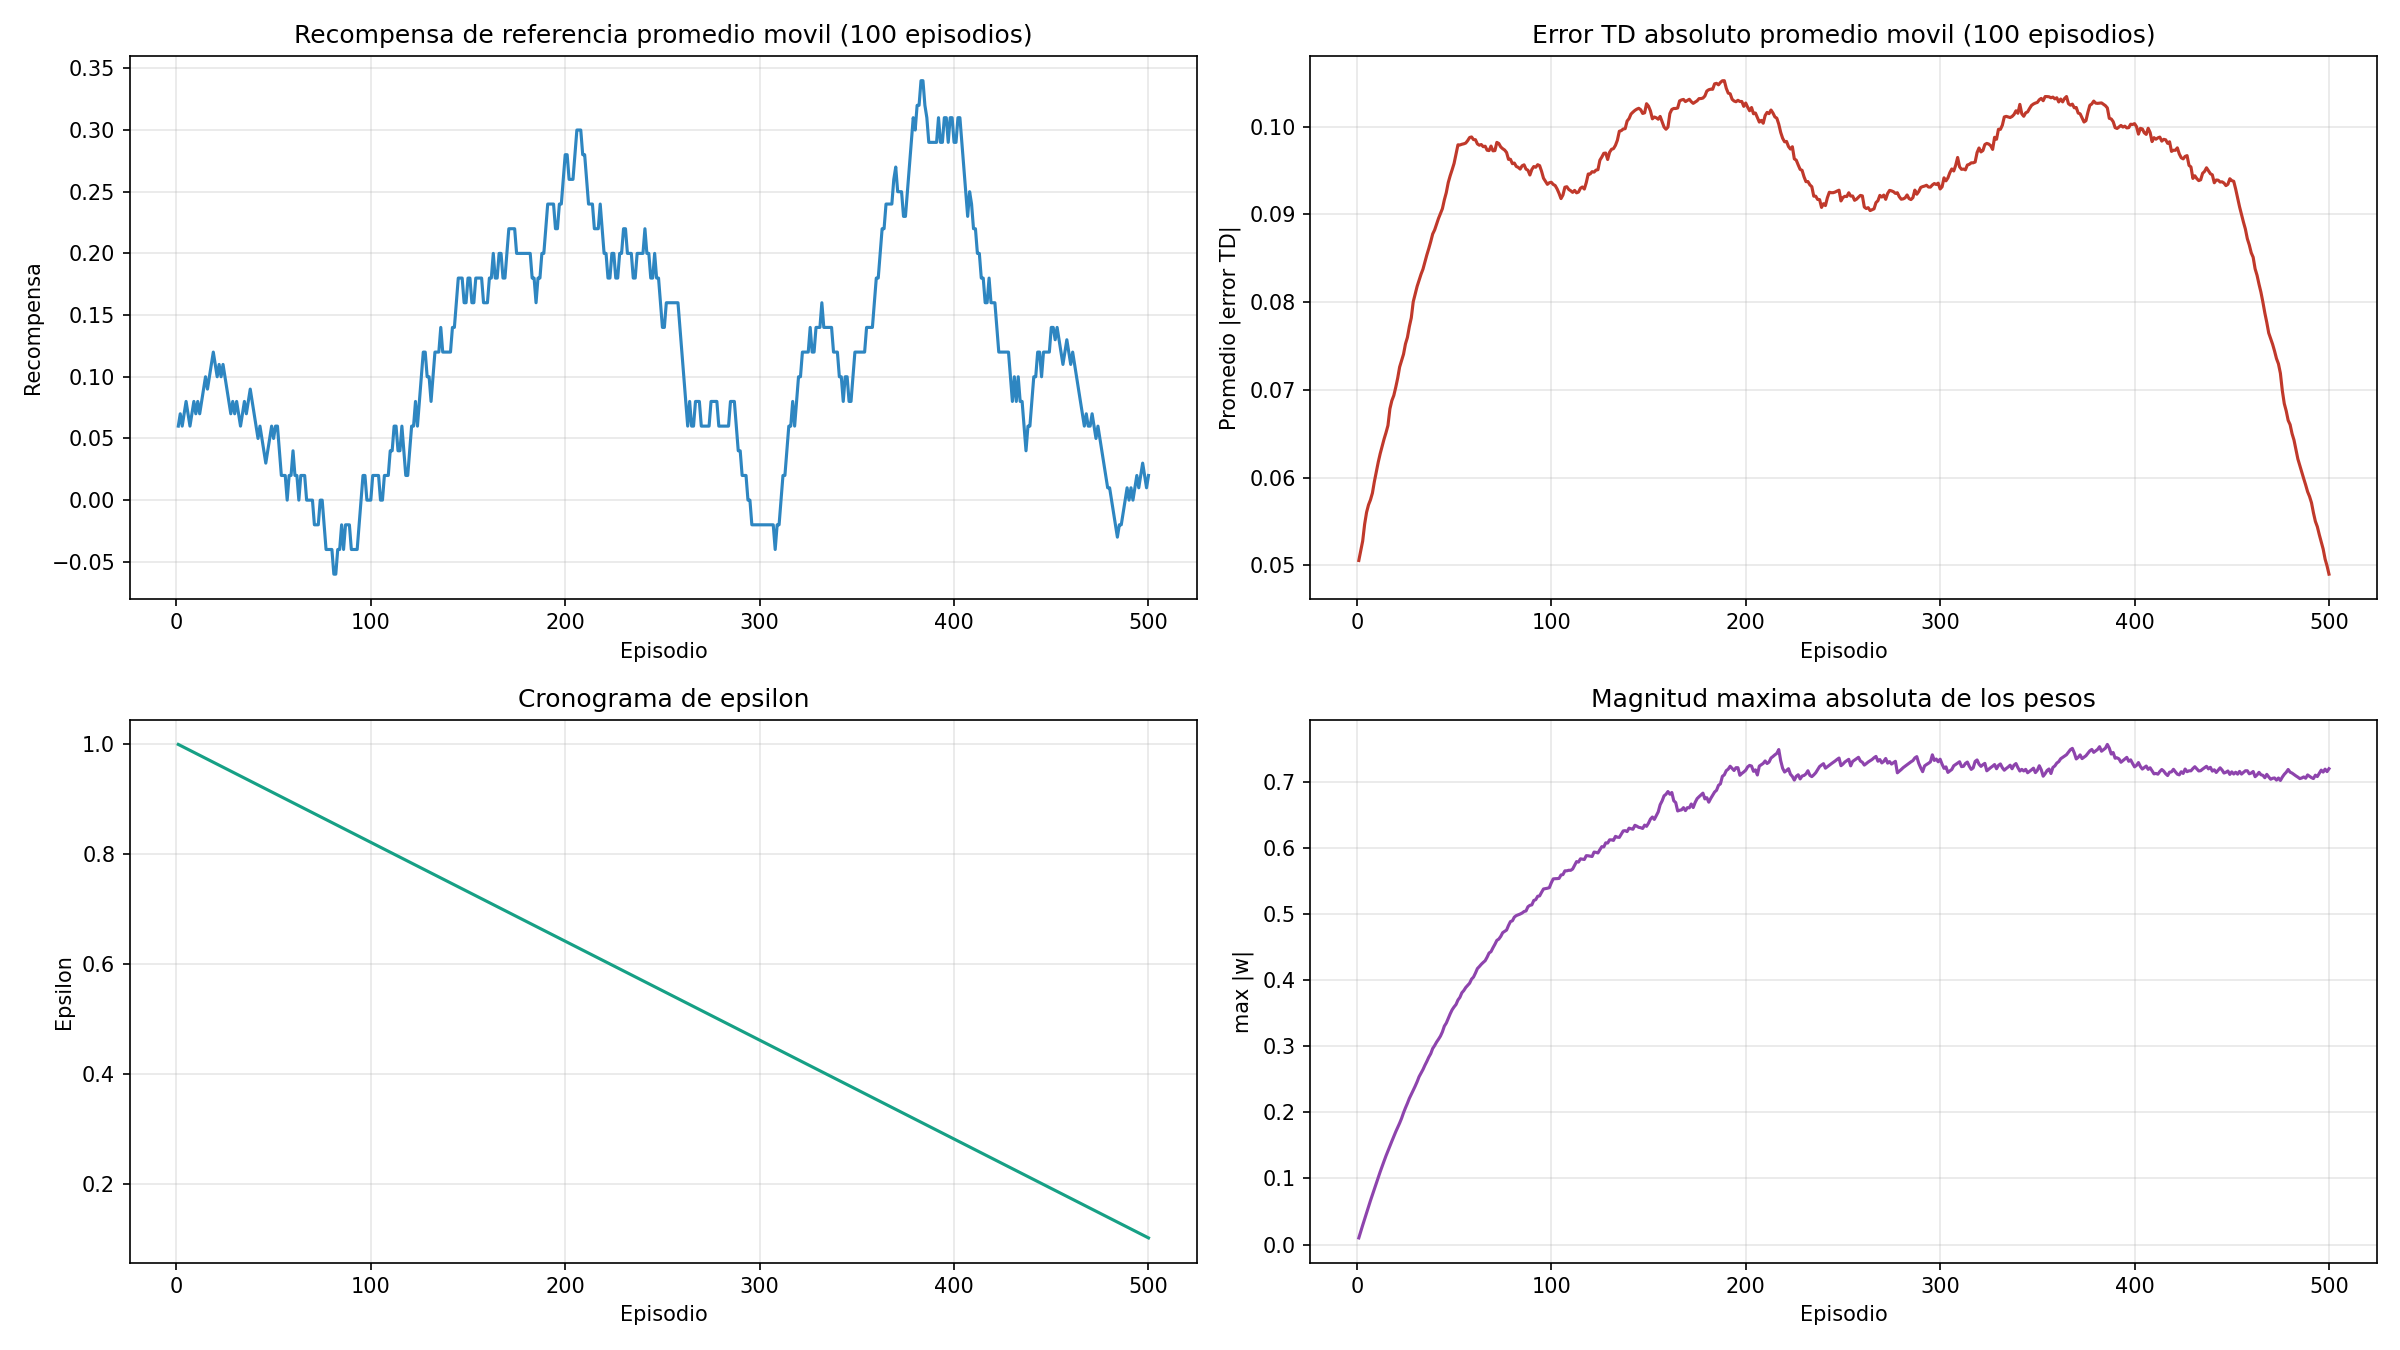

Imagen de entrenamiento: C:\Users\djlop\OneDrive\DIEGO\UVG\2026\primer semestre\IA\Labs\artifacts\task2_full\notebook_visuals\training_overview.png
Epsilon final: 0.1018
Checkpoints guardados: 1
Peso maximo absoluto final: 0.719414810218834


In [5]:
episode_logs = result["training"]["episode_logs"]
required_training_keys = {
    "episode",
    "reference_reward",
    "mean_abs_td_error",
    "epsilon",
    "weight_max_abs",
    "nonfinite_detected",
}
missing_training_keys = sorted(required_training_keys - set(episode_logs[0].keys())) if episode_logs else []
if missing_training_keys:
    raise ValueError(
        "El resumen de entrenamiento no usa el esquema actual. "
        f"Faltan llaves: {missing_training_keys}. "
        "Vuelve a correr el pipeline desde cero en este notebook."
    )

episodes = np.array([row["episode"] for row in episode_logs], dtype=float)
rewards = np.array([row["reference_reward"] for row in episode_logs], dtype=float)
td_errors = np.array([row["mean_abs_td_error"] for row in episode_logs], dtype=float)
epsilons = np.array([row["epsilon"] for row in episode_logs], dtype=float)
weight_max_abs = np.array([row["weight_max_abs"] for row in episode_logs], dtype=float)
nonfinite_detected = any(row["nonfinite_detected"] for row in episode_logs)

if nonfinite_detected:
    raise ValueError("Se detectaron valores no finitos durante el entrenamiento.")

for series_name, series_values in {
    "recompensas": rewards,
    "errores_td": td_errors,
    "epsilons": epsilons,
    "weight_max_abs": weight_max_abs,
}.items():
    if not np.isfinite(series_values).all():
        raise ValueError(f"La serie {series_name} contiene valores no finitos.")

def moving_average(values, window=100):
    if len(values) == 0:
        return values
    window = max(1, min(window, len(values)))
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(values, kernel, mode="same")

reward_ma = moving_average(rewards, window=100)
td_error_ma = moving_average(td_errors, window=100)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()
axes[0].plot(episodes, reward_ma, color="#2E86C1")
axes[0].set_title("Recompensa de referencia promedio movil (100 episodios)")
axes[0].set_xlabel("Episodio")
axes[0].set_ylabel("Recompensa")
axes[0].grid(True, alpha=0.3)

axes[1].plot(episodes, td_error_ma, color="#C0392B")
axes[1].set_title("Error TD absoluto promedio movil (100 episodios)")
axes[1].set_xlabel("Episodio")
axes[1].set_ylabel("Promedio |error TD|")
axes[1].grid(True, alpha=0.3)

axes[2].plot(episodes, epsilons, color="#16A085")
axes[2].set_title("Cronograma de epsilon")
axes[2].set_xlabel("Episodio")
axes[2].set_ylabel("Epsilon")
axes[2].grid(True, alpha=0.3)

axes[3].plot(episodes, weight_max_abs, color="#8E44AD")
axes[3].set_title("Magnitud maxima absoluta de los pesos")
axes[3].set_xlabel("Episodio")
axes[3].set_ylabel("max |w|")
axes[3].grid(True, alpha=0.3)

training_plot_path = VISUALS_DIR / "training_overview.png"
fig.tight_layout()
fig.savefig(training_plot_path, dpi=150)
plt.close(fig)
display(Image(filename=str(training_plot_path)))

print("Imagen de entrenamiento:", training_plot_path)
print("Epsilon final:", result["training"]["final_epsilon"])
print("Checkpoints guardados:", len(result["training"]["checkpoints"]))
print("Peso maximo absoluto final:", weight_max_abs[-1])


## Resumen de Evaluacion

In [6]:
for condition, condition_summary in result["evaluation"]["conditions"].items():
    agent1_label = condition_summary["agent1_label"]
    agent2_label = condition_summary["agent2_label"]
    wins = condition_summary["wins"]
    losses = condition_summary["losses"]
    draws = condition_summary["draws"]
    num_matches = condition_summary["num_matches"]
    print(f"Condicion {condition}: {agent1_label} vs {agent2_label}")
    print(f"  Victorias: {wins}")
    print(f"  Derrotas:  {losses}")
    print(f"  Empates:   {draws}")
    print(f"  Partidas:  {num_matches}")
    print()


Condicion A: TD vs Minimax
  Victorias: 50
  Derrotas:  0
  Empates:   0
  Partidas:  50

Condicion B: TD vs AlphaBeta
  Victorias: 50
  Derrotas:  0
  Empates:   0
  Partidas:  50

Condicion C: Minimax vs AlphaBeta
  Victorias: 25
  Derrotas:  25
  Empates:   0
  Partidas:  50



## Figura de Task 2

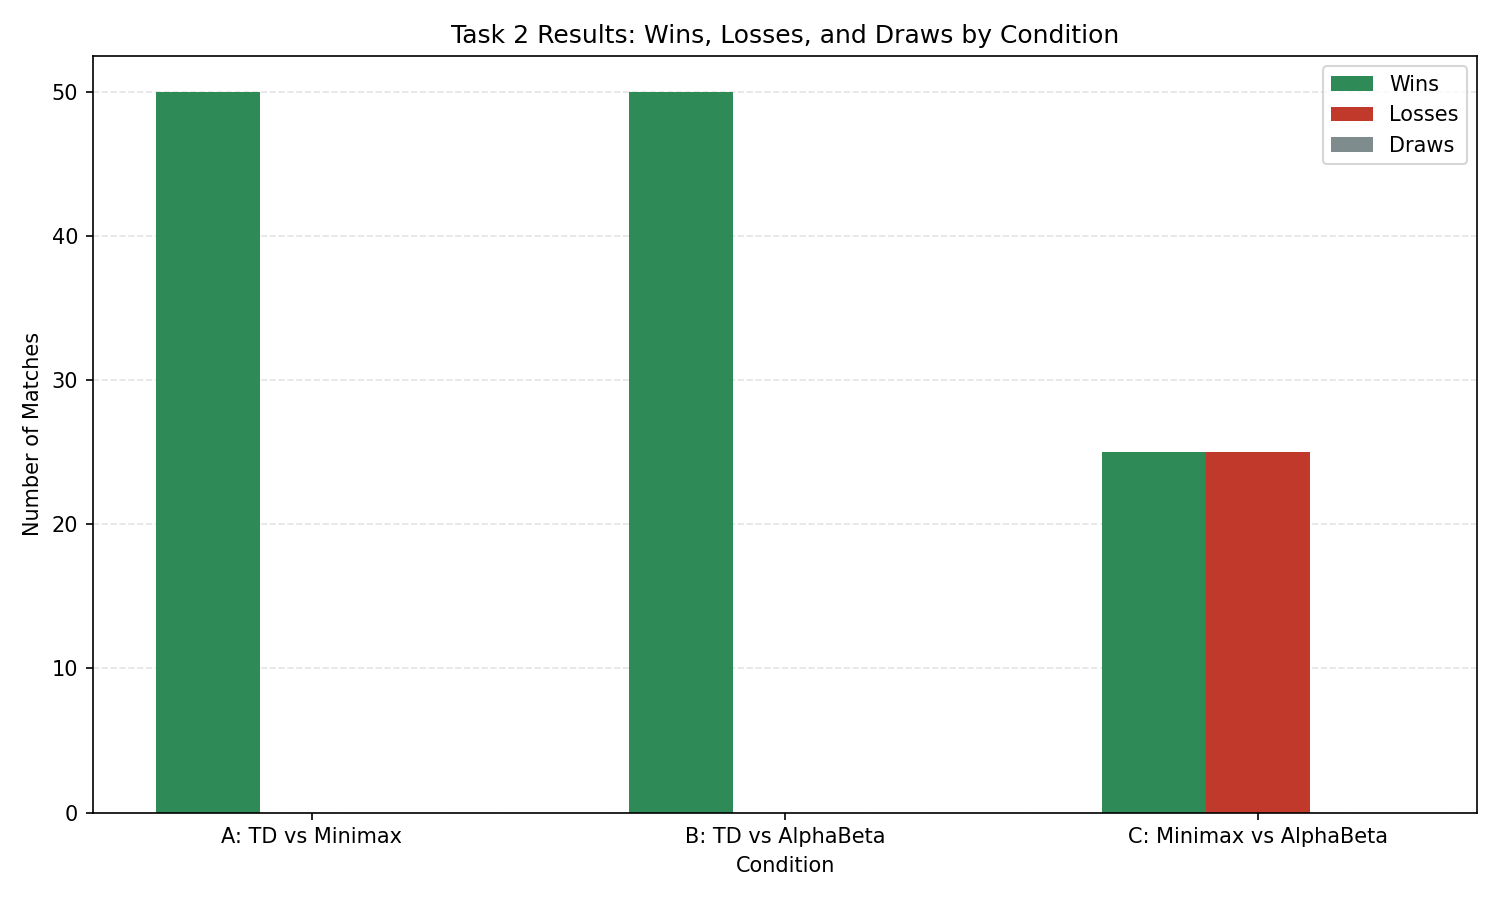

Figura PNG: C:\Users\djlop\OneDrive\DIEGO\UVG\2026\primer semestre\IA\Labs\artifacts\task2_full\notebook_visuals\task2_results.png
PDF exportado en: C:\Users\djlop\OneDrive\DIEGO\UVG\2026\primer semestre\IA\Labs\artifacts\task2_full\task2_results.pdf


In [7]:
fig, counts = create_task2_results_figure(result["evaluation"])
figure_png_path = VISUALS_DIR / "task2_results.png"
fig.savefig(figure_png_path, dpi=150)
plt.close(fig)
display(Image(filename=str(figure_png_path)))
print("Figura PNG:", figure_png_path)
print("PDF exportado en:", result["report"]["pdf_path"])


## Resumen de Analisis

In [8]:
analysis_summary = result["analysis"]["analysis_summary"]
print(json.dumps(analysis_summary, indent=2, ensure_ascii=False))


{
  "matches_per_condition": 50,
  "conditions": {
    "A": {
      "agent1_label": "TD",
      "agent2_label": "Minimax",
      "wins": 50,
      "losses": 0,
      "draws": 0,
      "num_matches": 50
    },
    "B": {
      "agent1_label": "TD",
      "agent2_label": "AlphaBeta",
      "wins": 50,
      "losses": 0,
      "draws": 0,
      "num_matches": 50
    },
    "C": {
      "agent1_label": "Minimax",
      "agent2_label": "AlphaBeta",
      "wins": 25,
      "losses": 25,
      "draws": 0,
      "num_matches": 50
    }
  },
  "overall_winner_counts": {
    "TD": 100,
    "AlphaBeta": 25,
    "Minimax": 25
  },
  "overall_draws": 0,
  "most_frequent_winner_labels": [
    "TD"
  ],
  "max_wins": 100
}


## Partidas Representativas

Condicion A: TD vs Minimax
  Inicio:   TD
  Ganador:  TD
  Jugadas:  19


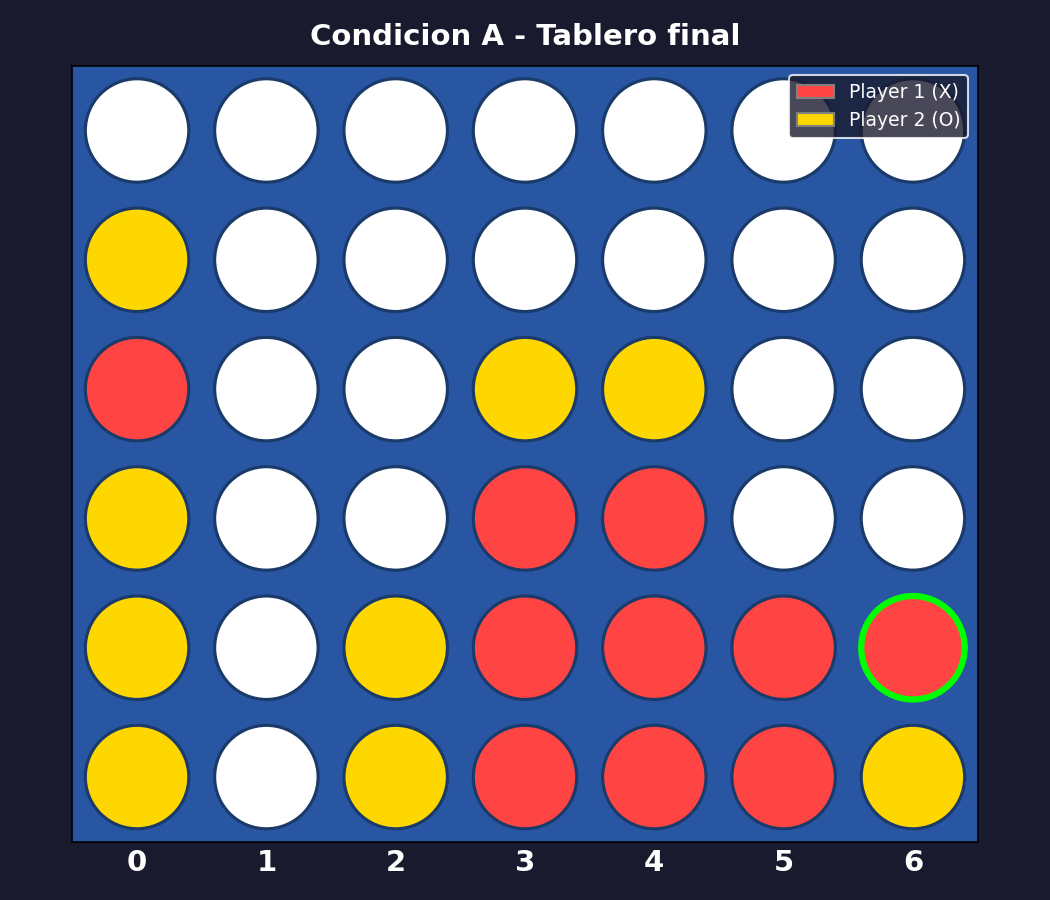

Condicion B: TD vs AlphaBeta
  Inicio:   TD
  Ganador:  TD
  Jugadas:  19


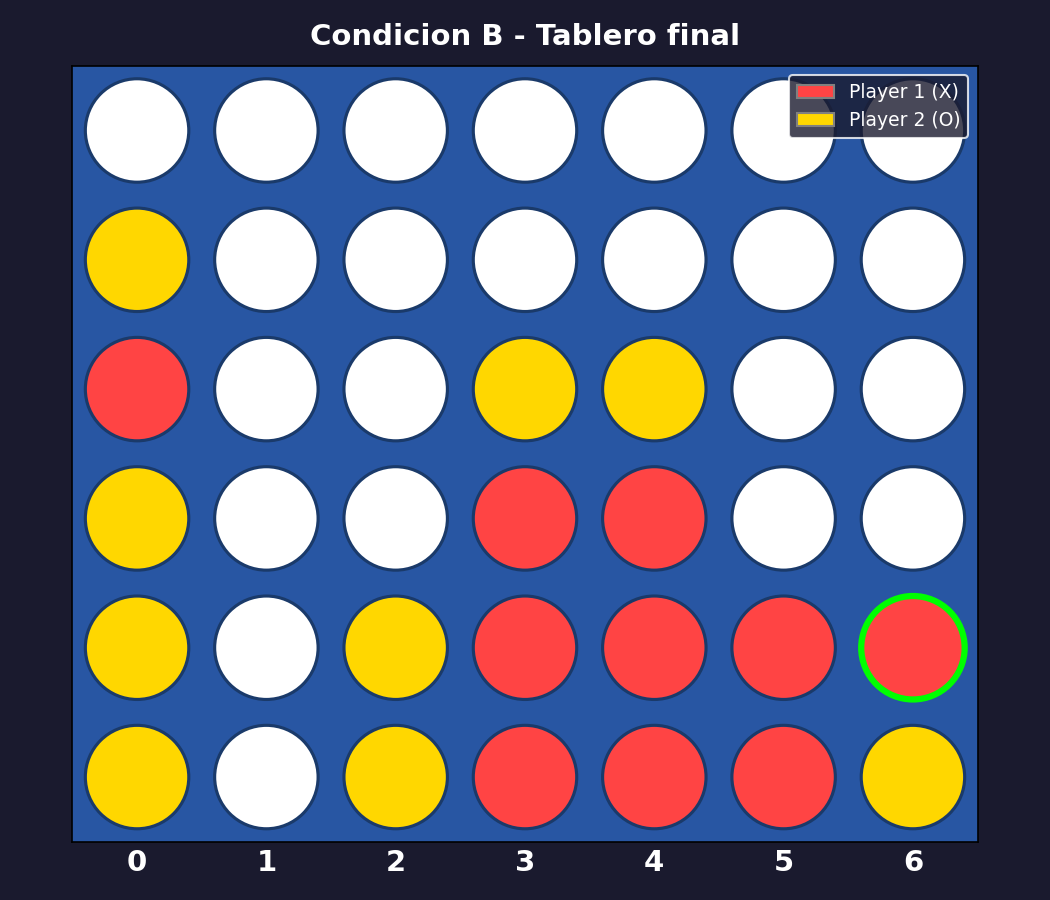

Condicion C: Minimax vs AlphaBeta
  Inicio:   Minimax
  Ganador:  AlphaBeta
  Jugadas:  38


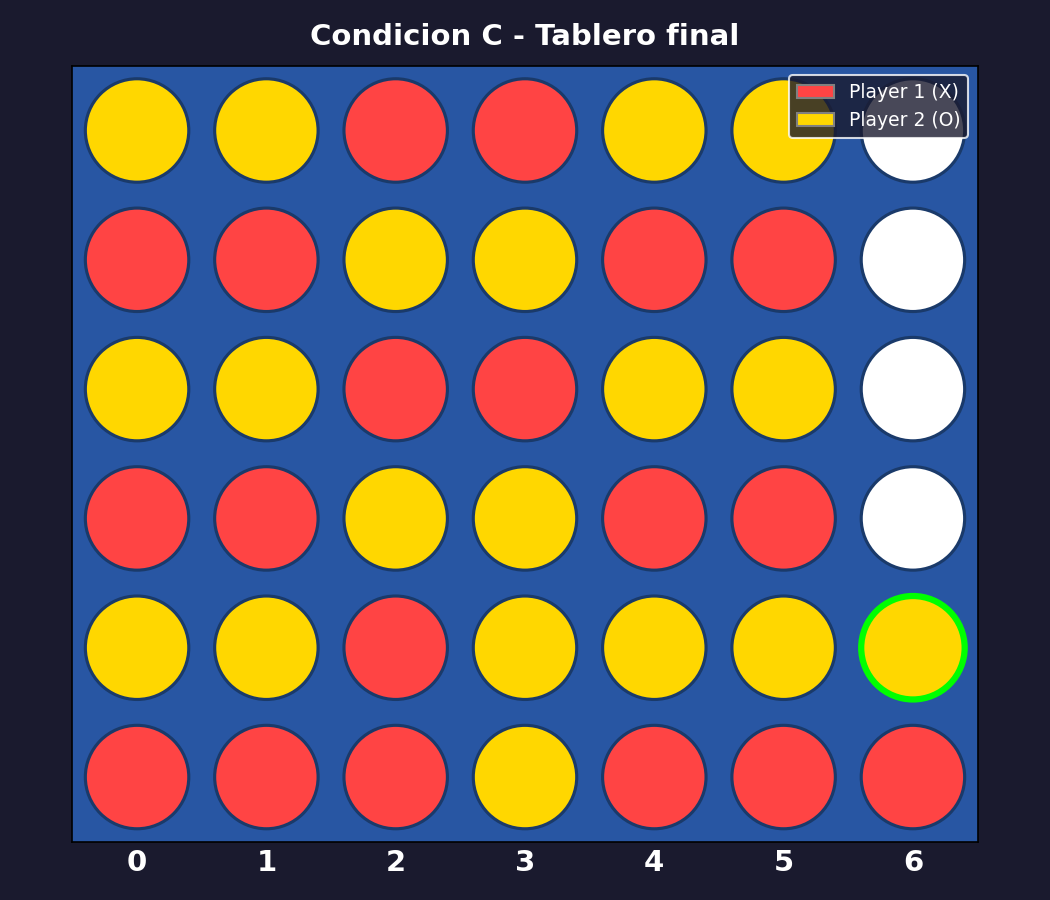

In [9]:
def td_match_uses_leftmost_policy(match):
    game = Connect4()
    for move in match["moves"]:
        acting_label = match["player1_label"] if move["player"] == Connect4.PLAYER1 else match["player2_label"]
        legal_min = min(game.actions())
        if acting_label == "TD" and move["column"] != legal_min:
            return False
        game.drop_piece(move["column"])
    return True

td_matches = []
for condition in ("A", "B"):
    td_matches.extend(result["evaluation"]["conditions"][condition]["matches"])

if td_matches and all(td_match_uses_leftmost_policy(match) for match in td_matches):
    raise ValueError("Se detecto una politica degenerada del agente TD: siempre elige la columna legal mas a la izquierda.")

representative_matches = extract_representative_matches(result["evaluation"])
representative_image_paths = {}

for condition, match in representative_matches.items():
    agent1_label = match["agent1_label"]
    agent2_label = match["agent2_label"]
    starter_label = match["starter_label"]
    winner_label = match["winner_label"] if match["winner_label"] else "Empate"
    move_count = match["move_count"]
    print(f"Condicion {condition}: {agent1_label} vs {agent2_label}")
    print(f"  Inicio:   {starter_label}")
    print(f"  Ganador:  {winner_label}")
    print(f"  Jugadas:  {move_count}")
    frames = replay_match_states(match)
    final_frame = frames[-1]
    fig, _ = create_board_figure(
        Connect4(board=final_frame["board"]),
        title=f"Condicion {condition} - Tablero final",
        last_move=tuple(final_frame["last_move"]) if final_frame["last_move"] is not None else None,
    )
    image_path = VISUALS_DIR / f"representative_condition_{condition}.png"
    fig.savefig(image_path, dpi=150)
    plt.close(fig)
    representative_image_paths[condition] = image_path
    display(Image(filename=str(image_path)))


## Visuales Exportados

In [10]:
print("Exportaciones visuales del notebook:")
for path in sorted(VISUALS_DIR.glob("*")):
    print(" ", path)


Exportaciones visuales del notebook:
  C:\Users\djlop\OneDrive\DIEGO\UVG\2026\primer semestre\IA\Labs\artifacts\task2_full\notebook_visuals\representative_condition_A.png
  C:\Users\djlop\OneDrive\DIEGO\UVG\2026\primer semestre\IA\Labs\artifacts\task2_full\notebook_visuals\representative_condition_B.png
  C:\Users\djlop\OneDrive\DIEGO\UVG\2026\primer semestre\IA\Labs\artifacts\task2_full\notebook_visuals\representative_condition_C.png
  C:\Users\djlop\OneDrive\DIEGO\UVG\2026\primer semestre\IA\Labs\artifacts\task2_full\notebook_visuals\task2_results.png
  C:\Users\djlop\OneDrive\DIEGO\UVG\2026\primer semestre\IA\Labs\artifacts\task2_full\notebook_visuals\training_overview.png


## Repeticion Opcional

In [11]:
def replay_condition(condition, delay=0.35):
    match = representative_matches[condition]
    frames = replay_match_states(match)
    for frame in frames:
        clear_output(wait=True)
        ply = frame["ply"]
        title = f"Condicion {condition} | Movimiento {ply}"
        fig, _ = create_board_figure(
            Connect4(board=frame["board"]),
            title=title,
            last_move=tuple(frame["last_move"]) if frame["last_move"] is not None else None,
        )
        display(fig)
        plt.close(fig)
        time.sleep(delay)

print('Usa replay_condition("A"), replay_condition("B"), o replay_condition("C") para animar una partida representativa.')


Usa replay_condition("A"), replay_condition("B"), o replay_condition("C") para animar una partida representativa.
